# Ejercicio 4 - Analisis exploratorio con DuckDB

Ejecuta las consultas de `sql/ex4_analisis.sql` directamente sobre los Parquet de `data/raw/`
y genera las graficas en `docs/img/`. Preguntas, interpretacion y hallazgos: `docs/ejercicio4.md`.

Requisito: `python scripts/download_data.py` (descarga tambien `taxi_zone_lookup.csv`).

In [1]:
import os, sys, time
from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(RAIZ)
sys.path.insert(0, str(RAIZ / "scripts"))
from run_sql import dividir_bloques

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 250)

preparacion, bloques = dividir_bloques(Path("sql/ex4_analisis.sql").read_text(encoding="utf-8"))
con = duckdb.connect()
con.execute(preparacion)    # vistas viajes / viajes_validos / zonas (no copian datos)
consultas = dict(bloques)

def ejecutar(prefijo: str) -> pd.DataFrame:
    titulo, sql = next((t, s) for t, s in consultas.items() if t.startswith(prefijo + " "))
    inicio = time.perf_counter()
    df = con.sql(sql).df()
    print(f"{titulo}  ({time.perf_counter() - inicio:.2f} s)")
    return df

# Estilo comun: color por entidad (amarillo = yellow, verde = green), ejes discretos.
COLOR = {"yellow": "#eda100", "green": "#008300"}
ETIQUETA = {"yellow": "Amarillos", "green": "Verdes"}
TINTA, TINTA_2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": TINTA_2, "axes.titlecolor": TINTA,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": TINTA_2, "ytick.color": TINTA_2, "legend.frameon": False,
    "font.size": 10, "lines.linewidth": 2,
})
DIR_IMG = Path("docs/img"); DIR_IMG.mkdir(parents=True, exist_ok=True)

def guardar(fig, nombre):
    fig.tight_layout()
    fig.savefig(DIR_IMG / nombre, dpi=130)
    plt.show()

def barras_agrupadas(ax, categorias, valores_por_tipo, horizontal=False):
    """Barras agrupadas yellow/green con una pequena separacion y el valor como etiqueta."""
    n = len(categorias); ancho = 0.38
    for i, (tipo, valores) in enumerate(valores_por_tipo.items()):
        pos = [k + (i - 0.5) * (ancho + 0.03) for k in range(n)]
        if horizontal:
            barras = ax.barh(pos, valores, height=ancho, color=COLOR[tipo], label=ETIQUETA[tipo])
        else:
            barras = ax.bar(pos, valores, width=ancho, color=COLOR[tipo], label=ETIQUETA[tipo])
        ax.bar_label(barras, fmt="%.1f", fontsize=8, color=TINTA_2, padding=2)
    if horizontal:
        ax.set_yticks(range(n), categorias); ax.invert_yaxis(); ax.grid(axis="y", visible=False)
    else:
        ax.set_xticks(range(n), categorias); ax.grid(axis="x", visible=False)
    ax.legend()

## P1. ¿Cómo evoluciona el volumen mensual de viajes e ingresos por tipo?

In [2]:
mensual = ejecutar("Q4.1"); mensual

Q4.1 Volumen mensual de viajes e ingresos por tipo  (2.21 s)


,mes,tipo,viajes,viajes_por_dia,ingresos_musd,total_promedio
0,2026-01,yellow,3506093,113100.0,103.82,29.61
1,2026-02,yellow,3201435,114337.0,97.32,30.40
2,2026-03,yellow,3751767,121025.0,113.32,30.21
3,2026-04,yellow,3663832,122128.0,110.03,30.03
4,2026-05,yellow,3900951,125837.0,118.89,30.48
5,2026-06,yellow,3634844,121161.0,110.95,30.52
6,2026-07,yellow,3335681,107603.0,100.26,30.06
7,2026-08,yellow,3153755,101734.0,94.83,30.07
8,2026-01,green,38313,1236.0,0.93,24.22
9,2026-02,green,35380,1264.0,0.86,24.32


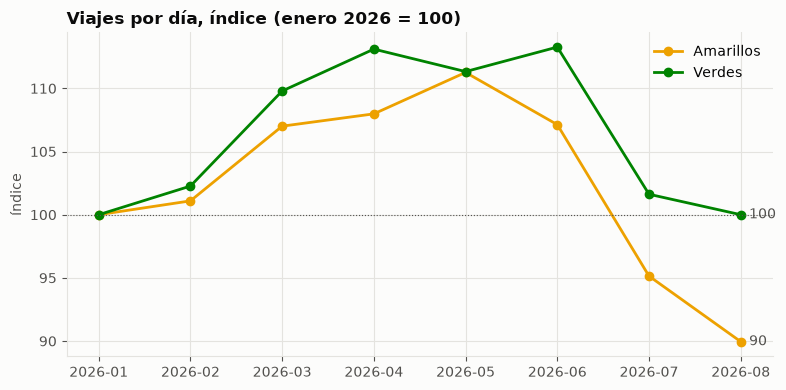

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
for tipo in ("yellow", "green"):
    d = mensual[mensual.tipo == tipo].sort_values("mes")
    indice = 100 * d.viajes_por_dia / d.viajes_por_dia.iloc[0]
    ax.plot(d.mes, indice, color=COLOR[tipo], marker="o", markersize=6, label=ETIQUETA[tipo])
    ax.annotate(f"{indice.iloc[-1]:.0f}", (d.mes.iloc[-1], indice.iloc[-1]),
                xytext=(6, 0), textcoords="offset points", va="center", color=TINTA_2)
ax.axhline(100, color=TINTA_2, linewidth=0.8, linestyle=":")
ax.set_title("Viajes por día, índice (enero 2026 = 100)")
ax.set_ylabel("índice"); ax.legend()
guardar(fig, "ex4_p1_viajes_mensuales.png")

## P2. ¿En qué horas y días se concentra la demanda?

In [4]:
horas = ejecutar("Q4.2"); horas

Q4.2 Distribucion de viajes por hora del dia (% del total de cada tipo)  (4.54 s)


,hora,pct_yellow,pct_green,duracion_mediana_yellow,velocidad_mediana_yellow
0,0,3.21,1.45,13.8,11.8
1,1,2.13,0.88,13.1,12.3
2,2,1.42,0.64,12.7,12.9
3,3,1.02,0.51,12.7,13.8
4,4,0.83,0.52,13.7,15.4
5,5,0.92,0.75,13.7,16.0
6,6,1.74,2.04,12.9,13.8
7,7,3.04,4.32,13.1,11.1
8,8,4.08,5.44,14.1,9.3
9,9,4.27,5.70,14.2,8.9


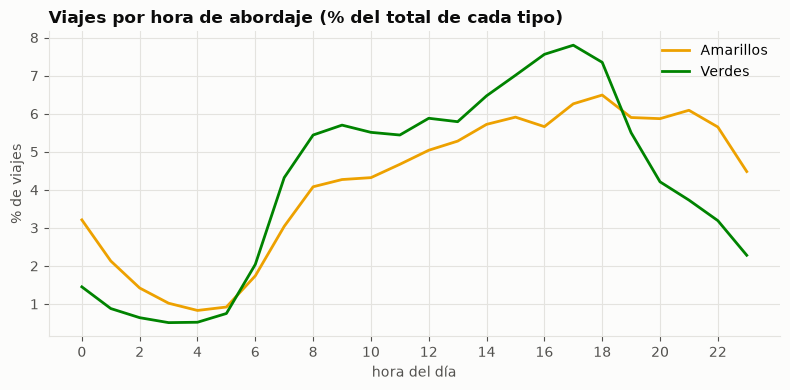

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
for tipo in ("yellow", "green"):
    ax.plot(horas.hora, horas[f"pct_{tipo}"], color=COLOR[tipo], label=ETIQUETA[tipo])
ax.set_xticks(range(0, 24, 2))
ax.set_title("Viajes por hora de abordaje (% del total de cada tipo)")
ax.set_xlabel("hora del día"); ax.set_ylabel("% de viajes"); ax.legend()
guardar(fig, "ex4_p2_viajes_por_hora.png")

In [6]:
semana = ejecutar("Q4.3"); semana

Q4.3 Viajes promedio por dia de la semana  (2.28 s)


,num_dia,dia,tipo,dias_observados,viajes_promedio_dia,pct_vs_promedio
0,1,Monday,yellow,35,95571.0,-17.5
1,2,Tuesday,yellow,34,112852.0,-2.6
2,3,Wednesday,yellow,34,120279.0,3.8
3,4,Thursday,yellow,35,127057.0,9.7
4,5,Friday,yellow,35,120283.0,3.8
5,6,Saturday,yellow,35,128254.0,10.7
6,7,Sunday,yellow,35,106604.0,-8.0
7,1,Monday,green,35,1306.0,-0.8
8,2,Tuesday,green,34,1425.0,8.3
9,3,Wednesday,green,34,1479.0,12.4


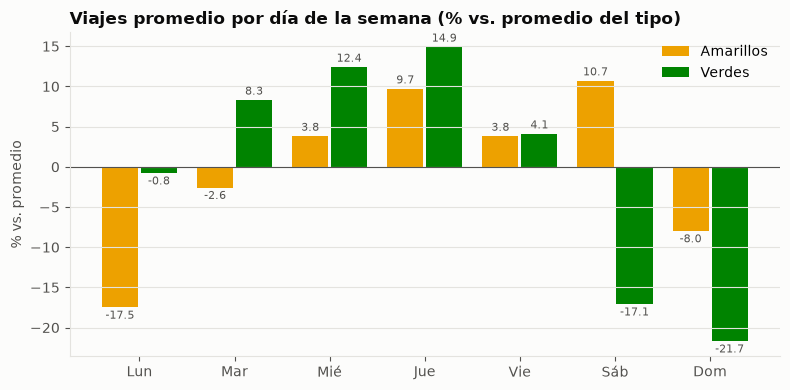

In [7]:
dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
fig, ax = plt.subplots(figsize=(8, 4))
barras_agrupadas(ax, dias, {t: semana[semana.tipo == t].sort_values("num_dia").pct_vs_promedio.tolist()
                            for t in ("yellow", "green")})
ax.axhline(0, color=TINTA_2, linewidth=0.8)
ax.set_title("Viajes promedio por día de la semana (% vs. promedio del tipo)")
ax.set_ylabel("% vs. promedio")
guardar(fig, "ex4_p2_dia_semana.png")

## P3 - P4. ¿Cómo es un viaje típico y cómo se distribuye la distancia?

In [8]:
ejecutar("Q4.4").T

Q4.4 Caracteristicas del viaje tipico por tipo de taxi  (9.35 s)


,0,1
tipo,yellow,green
viajes,28148358,319609
distancia_mediana_mi,1.94,2.17
distancia_promedio_mi,3.53,3.38
duracion_mediana_min,14.2,13.4
velocidad_mediana_mph,9.3,10.0
pasajeros_promedio,1.25,1.3
pct_un_pasajero,82.3,82.9
tarifa_mediana,15.6,13.5
total_mediano,23.58,20.52


In [9]:
dist = ejecutar("Q4.5"); dist

Q4.5 Distribucion de la distancia del viaje (% por rango)  (3.47 s)


,rango_distancia,pct_yellow,pct_green,total_mediano_yellow,total_mediano_green
0,1) < 1 mi,20.7,13.0,14.75,11.25
1,2) 1-2 mi,30.3,32.8,19.74,16.00
2,3) 2-5 mi,29.2,35.9,28.10,24.66
3,4) 5-10 mi,12.0,12.6,42.95,40.20
4,5) 10-20 mi,6.8,5.3,78.62,55.50
5,6) >= 20 mi,0.9,0.5,100.65,93.22


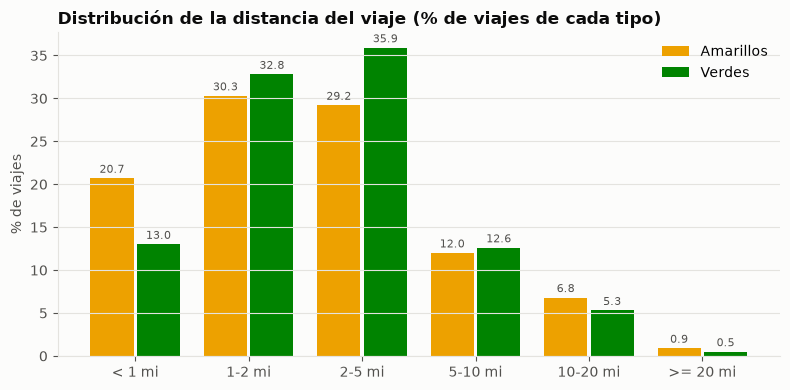

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
barras_agrupadas(ax, [r.split(") ")[1] for r in dist.rango_distancia],
                 {t: dist[f"pct_{t}"].tolist() for t in ("yellow", "green")})
ax.set_title("Distribución de la distancia del viaje (% de viajes de cada tipo)")
ax.set_ylabel("% de viajes")
guardar(fig, "ex4_p4_distancia.png")

## P5. ¿Dónde se originan los viajes?

In [11]:
borough = ejecutar("Q4.6"); borough

Q4.6 Borough de origen de los viajes (% por tipo)  (2.80 s)


,borough,pct_yellow,pct_green
0,Manhattan,86.74,59.83
1,Queens,8.75,21.80
2,Brooklyn,3.60,15.74
3,Bronx,0.78,2.47
4,Unknown,0.10,0.09
5,N/A,0.02,0.05
6,Staten Island,0.01,0.02
7,EWR,0.00,0.00


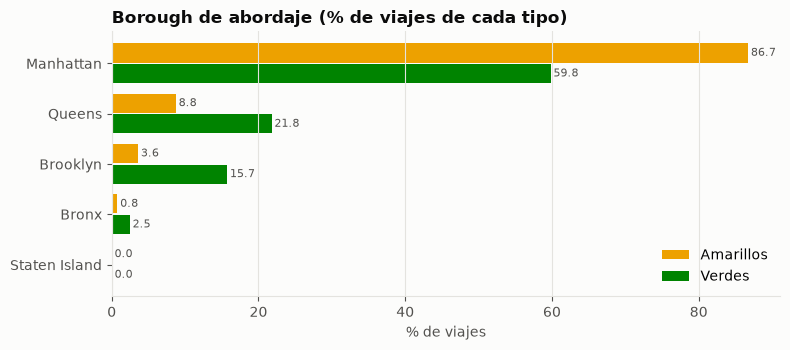

In [12]:
b = borough[borough.borough.isin(["Manhattan", "Queens", "Brooklyn", "Bronx", "Staten Island"])]
fig, ax = plt.subplots(figsize=(8, 3.6))
barras_agrupadas(ax, b.borough.tolist(), {t: b[f"pct_{t}"].tolist() for t in ("yellow", "green")},
                 horizontal=True)
ax.set_title("Borough de abordaje (% de viajes de cada tipo)"); ax.set_xlabel("% de viajes")
guardar(fig, "ex4_p5_borough.png")

In [13]:
ejecutar("Q4.7")

Q4.7 Diez zonas de abordaje con mas viajes por tipo  (2.71 s)


,tipo,ranking,borough,zona,viajes,pct_del_tipo
0,yellow,1,Manhattan,Upper East Side South,1250862,4.44
1,yellow,2,Manhattan,Midtown Center,1169840,4.16
2,yellow,3,Queens,JFK Airport,1112008,3.95
3,yellow,4,Manhattan,Upper East Side North,1111149,3.95
4,yellow,5,Manhattan,Penn Station/Madison Sq West,867486,3.08
5,yellow,6,Manhattan,Midtown East,863339,3.07
6,yellow,7,Manhattan,Times Sq/Theatre District,815655,2.90
7,yellow,8,Manhattan,Lincoln Square East,810586,2.88
8,yellow,9,Manhattan,East Village,755195,2.68
9,yellow,10,Manhattan,Murray Hill,736340,2.62


## P6 - P7. ¿Cómo se paga y cuánta propina se deja?

In [14]:
pago = ejecutar("Q4.8"); pago

Q4.8 Forma de pago por tipo de taxi (% de viajes)  (2.36 s)


,forma_pago,pct_yellow,pct_green,pct_yellow_con_info
0,0 sin informacion / flex fare,25.01,14.90,0.00
1,1 tarjeta de credito,65.40,65.59,87.21
2,2 efectivo,9.00,19.28,12.00
3,3 sin cargo,0.19,0.16,0.26
4,4 disputa,0.40,0.07,0.54
5,5 desconocido,0.00,0.00,0.00


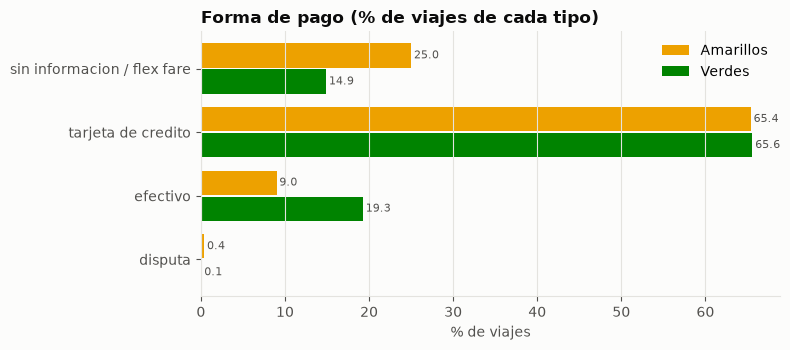

In [15]:
p = pago[pago.forma_pago.str[0].isin(list("0124"))]
fig, ax = plt.subplots(figsize=(8, 3.6))
barras_agrupadas(ax, [f[2:] for f in p.forma_pago], {t: p[f"pct_{t}"].tolist() for t in ("yellow", "green")},
                 horizontal=True)
ax.set_title("Forma de pago (% de viajes de cada tipo)"); ax.set_xlabel("% de viajes")
guardar(fig, "ex4_p6_forma_pago.png")

In [16]:
ejecutar("Q4.9")

Q4.9 Propinas segun la forma de pago  (3.56 s)


,tipo,forma_pago,viajes,pct_con_propina,propina_promedio,propina_pct_de_tarifa,propina_pct_mediana_si_deja
0,yellow,tarjeta,18409415,91.1,4.24,21.6,27.3
1,yellow,sin informacion,7038788,8.3,0.40,1.6,21.6
2,yellow,efectivo,2532774,0.0,0.00,0.0,27.6
3,yellow,otro,167381,0.0,0.00,0.0,26.9
4,green,tarjeta,209645,91.7,3.80,21.1,24.3
5,green,efectivo,61630,0.0,0.00,0.0,NaN
6,green,sin informacion,47607,15.5,0.76,8.0,20.8
7,green,otro,727,0.1,0.00,0.0,29.3


Q4.10 Propina con tarjeta segun la hora del dia  (1.80 s)


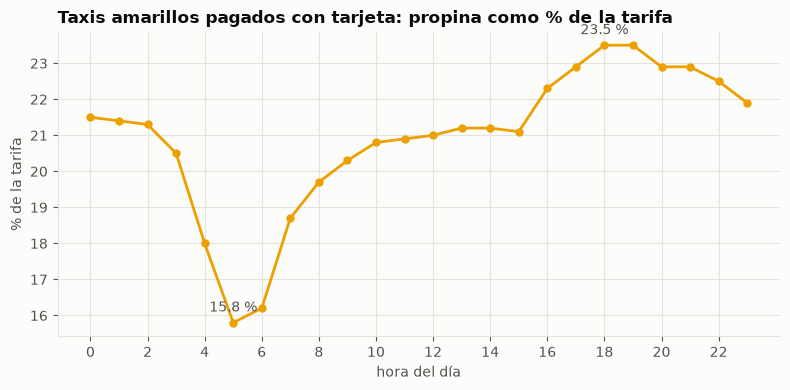

In [17]:
propina_hora = ejecutar("Q4.10")
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(propina_hora.hora, propina_hora.propina_pct_tarifa, color=COLOR["yellow"], marker="o", markersize=5)
for h in (5, 18):
    v = propina_hora.loc[propina_hora.hora == h, "propina_pct_tarifa"].iloc[0]
    ax.annotate(f"{v:.1f} %", (h, v), xytext=(0, 8), textcoords="offset points", ha="center", color=TINTA_2)
ax.set_xticks(range(0, 24, 2))
ax.set_title("Taxis amarillos pagados con tarjeta: propina como % de la tarifa")
ax.set_xlabel("hora del día"); ax.set_ylabel("% de la tarifa")
guardar(fig, "ex4_p7_propina_hora.png")

## P8 - P9. ¿De qué se compone el total? ¿Qué peso tienen aeropuertos y cuota CBD?

In [18]:
ejecutar("Q4.11")

Q4.11 Composicion del monto total (promedio por viaje, USD)  (3.07 s)


,tipo,tarifa,extra,mta_tax,improvement_surcharge,congestion_surcharge,cbd_congestion_fee,airport_fee,peajes,propina,total,pct_tarifa_en_total
0,yellow,21.23,1.17,0.50,0.98,2.26,0.54,0.17,0.55,2.88,30.18,70.3
1,green,16.71,0.84,0.56,0.92,0.92,0.06,0.00,0.30,2.60,25.38,65.8


In [19]:
ejecutar("Q4.12")

Q4.12 Viajes de aeropuerto y cuota de congestion CBD  (2.67 s)


,tipo,pct_viajes_aeropuerto,pct_ingresos_aeropuerto,total_mediano_aeropuerto,pct_con_cuota_cbd,cuota_cbd_musd
0,yellow,8.10,20.93,78.33,72.51,15.31
1,green,3.36,6.41,40.00,8.57,0.02


## P10. ¿Cuántos registros son atípicos o inconsistentes?

In [20]:
ejecutar("Q4.13")

Q4.13 Registros excluidos por motivo (valores atipicos e inconsistencias)  (2.23 s)


,tipo,motivo,registros,pct_del_tipo
0,yellow,(valido),28148358,94.76
1,yellow,distancia = 0,728621,2.45
2,yellow,duracion <= 0,371682,1.25
3,yellow,duracion < 1 min,309476,1.04
4,yellow,monto negativo,136567,0.46
5,yellow,duracion > 6 h,7309,0.02
6,yellow,distancia > 100 mi,1194,0.00
7,yellow,fecha fuera del mes del archivo,146,0.00
8,yellow,total >= 1000,2,0.00
9,green,(valido),319609,94.81


In [21]:
ejecutar("Q4.14")

Q4.14 Valores atipicos entre viajes validos (regla IQR y velocidad)  (7.85 s)


,tipo,tarifa_milla_q1,tarifa_milla_q3,limite_superior_iqr,atipicos_tarifa_milla,pct_atipicos_tarifa_milla,velocidad_mayor_80mph,tarifa_cero,tarifa_negociada
0,yellow,5.72,9.91,16.19,1577017,5.60,4233,12522,119499
1,green,5.33,8.14,12.36,14500,4.54,95,4723,10095
